In [ ]:
import pandas as pd
import numpy as np                  # Numerical operations
import pandas as pd                 # Data handling
import matplotlib.pyplot as plt     # Basic plotting
import seaborn as sns

!pip install scikit-fuzzy
import skfuzzy as fuzz
from skfuzzy import control as ctrl         # Advanced visualization

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

# Optional (for detailed statistical summary with p-values)
import statsmodels.api as sm
# Load the CSV file into a DataFrame
file_path = '/content/ai4i2020.csv'
df = pd.read_csv(file_path)

print("DataFrame Head:")
print(df.head())
print("\nDataFrame Info:")
df.info()
print("\nDataFrame Description:")
print(df.describe())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 24.3 MB/s eta 0:00:00
DataFrame Head:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9          

In [ ]:
# Air temperature
air_temp = ctrl.Antecedent(
    np.arange(df['Air temperature [K]'].min() - 1,
              df['Air temperature [K]'].max() + 1,
              0.1),
    'air_temp'
)

# Process temperature
process_temp = ctrl.Antecedent(
    np.arange(df['Process temperature [K]'].min() - 1,
              df['Process temperature [K]'].max() + 1,
              0.1),
    'process_temp'
)

# Rotational speed
rot_speed = ctrl.Antecedent(
    np.arange(df['Rotational speed [rpm]'].min() - 50,
              df['Rotational speed [rpm]'].max() + 50,
              1),
    'rot_speed'
)

# Torque
torque = ctrl.Antecedent(
    np.arange(df['Torque [Nm]'].min() - 1,
              df['Torque [Nm]'].max() + 1,
              0.5),
    'torque'
)

# Tool wear
tool_wear = ctrl.Antecedent(
    np.arange(df['Tool wear [min]'].min(),
              df['Tool wear [min]'].max() + 5,
              1),
    'tool_wear'
)

# Output variable
failure = ctrl.Consequent(
    np.arange(0, 1.01, 0.01),
    'failure'
)

In [ ]:
df['Machine failure'].value_counts()
df['Machine failure'].value_counts(normalize=True)

,proportion
Machine failure,
0,0.9661
1,0.0339


In [ ]:
failure_df = df[df['Machine failure'] == 1]
no_failure_df = df[df['Machine failure'] == 0]

df.groupby('Machine failure').mean(numeric_only=True)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
Machine failure,,,,,,,,,,,
0,5012.878791,299.973999,309.995570,1540.260014,39.629655,106.693717,0.000000,0.000000,0.000000,0.000000,0.001863
1,4647.722714,300.886431,310.290265,1496.486726,50.168142,143.781711,0.135693,0.339233,0.280236,0.289086,0.002950


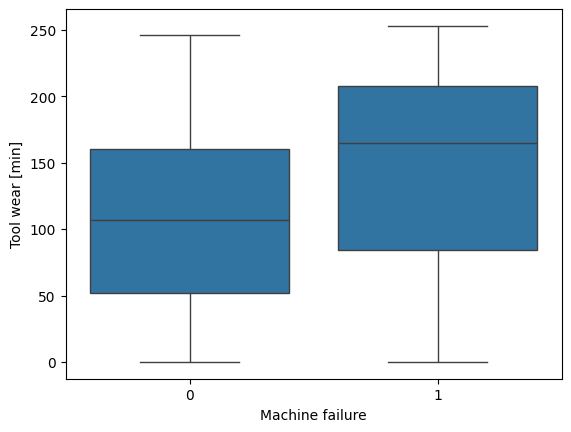

In [ ]:
sns.boxplot(x='Machine failure', y='Tool wear [min]', data=df)
plt.show()

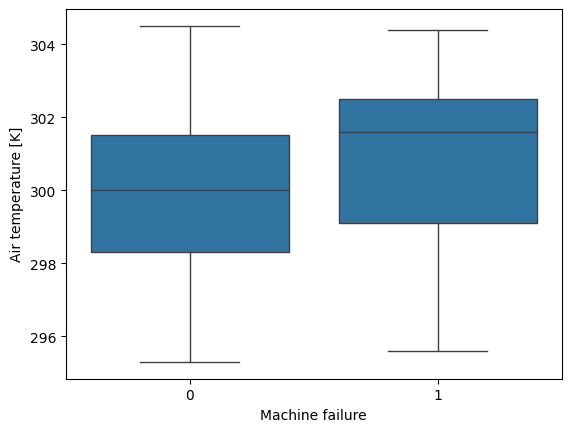

In [ ]:
sns.boxplot(x='Machine failure', y='Air temperature [K]', data=df)
plt.show()

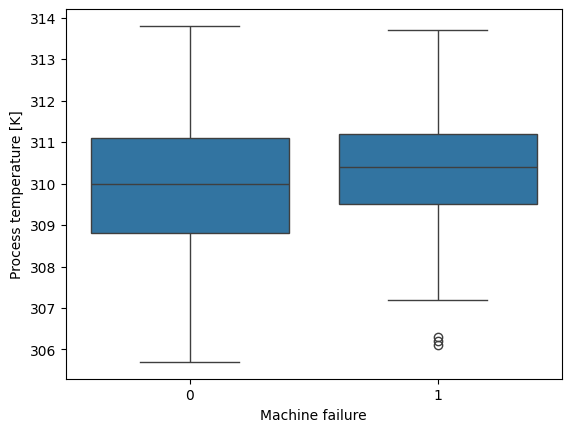

In [ ]:
sns.boxplot(x='Machine failure', y='Process temperature [K]', data=df)
plt.show()

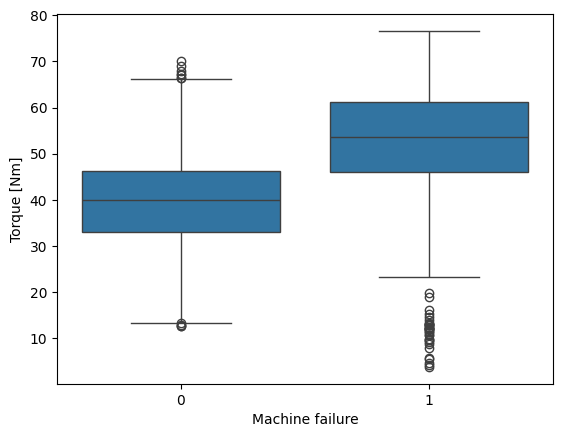

In [ ]:
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)
plt.show()

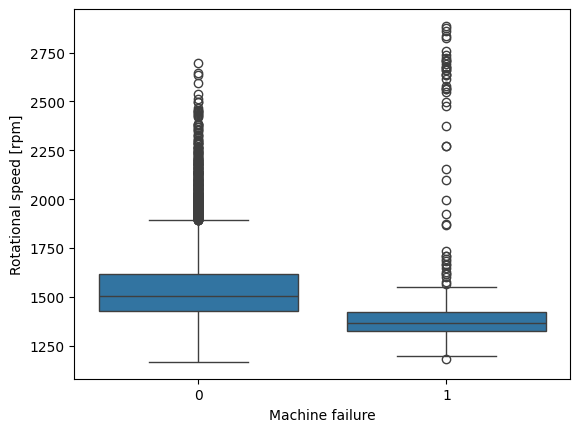

In [ ]:
sns.boxplot(x='Machine failure', y='Rotational speed [rpm]', data=df)
plt.show()

In [ ]:
df.corr(numeric_only=True)['Machine failure'].sort_values(ascending=False)

,Machine failure
Machine failure,1.000000
HDF,0.575800
OSF,0.531083
PWF,0.522812
TWF,0.362904
Torque [Nm],0.191321
Tool wear [min],0.105448
Air temperature [K],0.082556
Process temperature [K],0.035946
RNF,0.004516


In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Get percentiles
stats = {}

columns = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for col in columns:
    stats[col] = {
        "min": df[col].min(),
        "q1": df[col].quantile(0.25),
        "median": df[col].quantile(0.5),
        "q3": df[col].quantile(0.75),
        "max": df[col].max()
    }

In [ ]:
air_temp = ctrl.Antecedent(
    np.arange(stats['Air temperature [K]']['min'] - 1,
              stats['Air temperature [K]']['max'] + 1, 0.1),
    'air_temp'
)

air_temp['low'] = fuzz.trimf(
    air_temp.universe,
    [stats['Air temperature [K]']['min'],
     stats['Air temperature [K]']['min'],
     stats['Air temperature [K]']['median']]
)

air_temp['medium'] = fuzz.trimf(
    air_temp.universe,
    [stats['Air temperature [K]']['q1'],
     stats['Air temperature [K]']['median'],
     stats['Air temperature [K]']['q3']]
)

air_temp['high'] = fuzz.trimf(
    air_temp.universe,
    [stats['Air temperature [K]']['median'],
     stats['Air temperature [K]']['max'],
     stats['Air temperature [K]']['max']]
)

In [ ]:
process_temp = ctrl.Antecedent(
    np.arange(stats['Process temperature [K]']['min'] - 1,
              stats['Process temperature [K]']['max'] + 1, 0.1),
    'process_temp'
)

process_temp['low'] = fuzz.trimf(
    process_temp.universe,
    [stats['Process temperature [K]']['min'],
     stats['Process temperature [K]']['min'],
     stats['Process temperature [K]']['median']]
)

process_temp['medium'] = fuzz.trimf(
    process_temp.universe,
    [stats['Process temperature [K]']['q1'],
     stats['Process temperature [K]']['median'],
     stats['Process temperature [K]']['q3']]
)

process_temp['high'] = fuzz.trimf(
    process_temp.universe,
    [stats['Process temperature [K]']['median'],
     stats['Process temperature [K]']['max'],
     stats['Process temperature [K]']['max']]
)

In [ ]:
rot_speed = ctrl.Antecedent(
    np.arange(stats['Rotational speed [rpm]']['min'] - 50,
              stats['Rotational speed [rpm]']['max'] + 50, 1),
    'rot_speed'
)

rot_speed['low'] = fuzz.trimf(
    rot_speed.universe,
    [stats['Rotational speed [rpm]']['min'],
     stats['Rotational speed [rpm]']['min'],
     stats['Rotational speed [rpm]']['median']]
)

rot_speed['medium'] = fuzz.trimf(
    rot_speed.universe,
    [stats['Rotational speed [rpm]']['q1'],
     stats['Rotational speed [rpm]']['median'],
     stats['Rotational speed [rpm]']['q3']]
)

rot_speed['high'] = fuzz.trimf(
    rot_speed.universe,
    [stats['Rotational speed [rpm]']['median'],
     stats['Rotational speed [rpm]']['max'],
     stats['Rotational speed [rpm]']['max']]
)

In [ ]:
torque = ctrl.Antecedent(
    np.arange(stats['Torque [Nm]']['min'] - 1,
              stats['Torque [Nm]']['max'] + 1, 0.5),
    'torque'
)

torque['low'] = fuzz.trimf(
    torque.universe,
    [stats['Torque [Nm]']['min'],
     stats['Torque [Nm]']['min'],
     stats['Torque [Nm]']['median']]
)

torque['medium'] = fuzz.trimf(
    torque.universe,
    [stats['Torque [Nm]']['q1'],
     stats['Torque [Nm]']['median'],
     stats['Torque [Nm]']['q3']]
)

torque['high'] = fuzz.trimf(
    torque.universe,
    [stats['Torque [Nm]']['median'],
     stats['Torque [Nm]']['max'],
     stats['Torque [Nm]']['max']]
)

In [ ]:
tool_wear = ctrl.Antecedent(
    np.arange(stats['Tool wear [min]']['min'],
              stats['Tool wear [min]']['max'] + 5, 1),
    'tool_wear'
)

tool_wear['low'] = fuzz.trimf(
    tool_wear.universe,
    [stats['Tool wear [min]']['min'],
     stats['Tool wear [min]']['min'],
     stats['Tool wear [min]']['median']]
)

tool_wear['medium'] = fuzz.trimf(
    tool_wear.universe,
    [stats['Tool wear [min]']['q1'],
     stats['Tool wear [min]']['median'],
     stats['Tool wear [min]']['q3']]
)

tool_wear['high'] = fuzz.trimf(
    tool_wear.universe,
    [stats['Tool wear [min]']['median'],
     stats['Tool wear [min]']['max'],
     stats['Tool wear [min]']['max']]
)

In [ ]:
maintenance = ctrl.Consequent(
    np.arange(0, 1.01, 0.01),
    'maintenance'
)

maintenance['green'] = fuzz.trimf(maintenance.universe, [0, 0, 0.5])
maintenance['yellow'] = fuzz.trimf(maintenance.universe, [0.3, 0.5, 0.7])
maintenance['red'] = fuzz.trimf(maintenance.universe, [0.6, 1, 1])

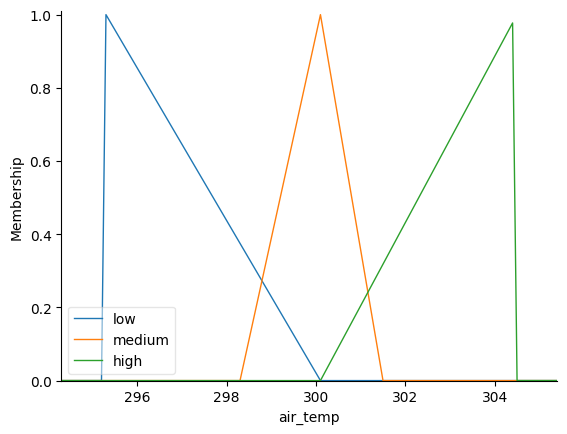

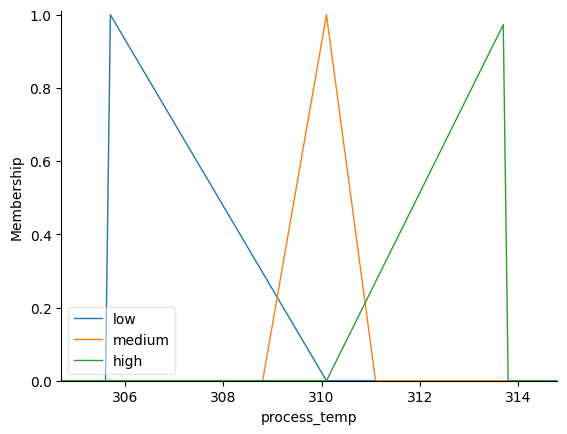

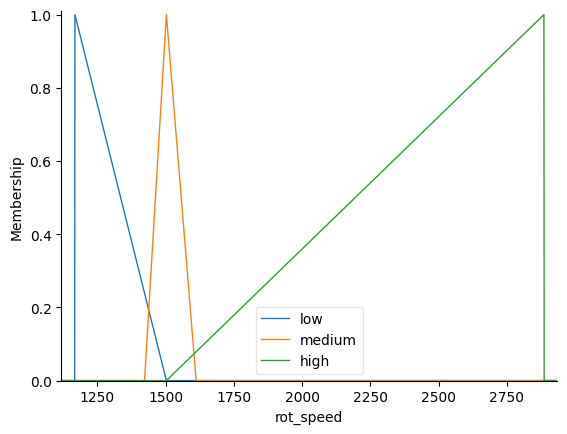

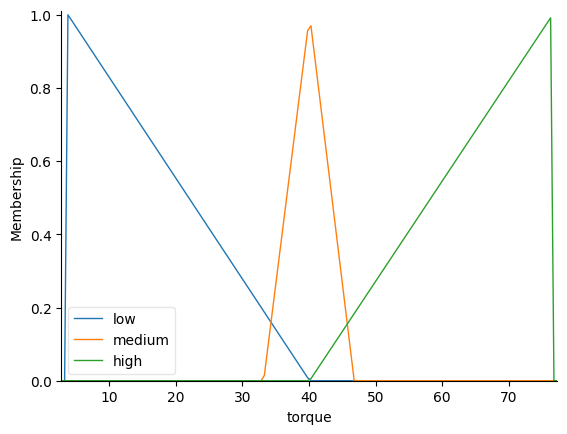

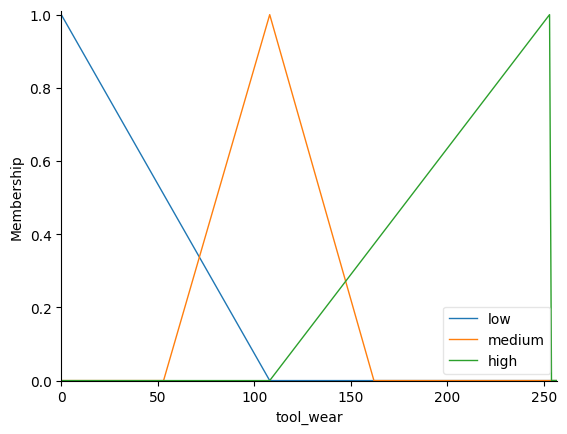

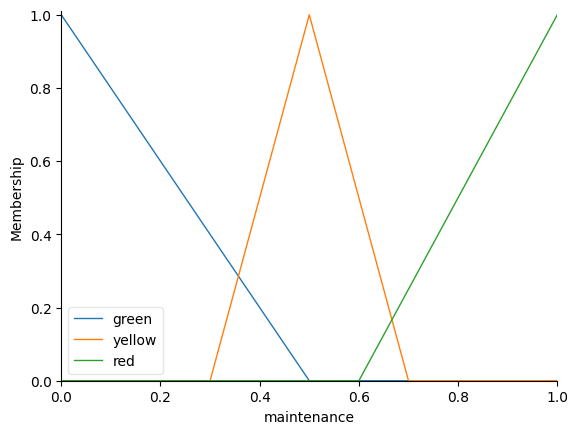

In [ ]:
air_temp.view()
process_temp.view()
rot_speed.view()
torque.view()
tool_wear.view()
maintenance.view()

In [ ]:
rule1 = ctrl.Rule(
    tool_wear['high'] & torque['high'],
    maintenance['red']
)

rule2 = ctrl.Rule(
    (tool_wear['medium'] | tool_wear['high']) & torque['high'],
    maintenance['red']
)

rule3 = ctrl.Rule(
    rot_speed['low'] & torque['high'],
    maintenance['red']
)

In [ ]:
rule4 = ctrl.Rule(
    process_temp['high'],
    maintenance['yellow']
)

rule5 = ctrl.Rule(
    tool_wear['medium'],
    maintenance['yellow']
)

rule6 = ctrl.Rule(
    tool_wear['low'] & torque['medium'],
    maintenance['yellow']
)

rule7 = ctrl.Rule(
    rot_speed['low'] & tool_wear['medium'],
    maintenance['yellow']
)

In [ ]:
rule8 = ctrl.Rule(
    tool_wear['low'] &
    torque['low'] &
    (process_temp['low'] | process_temp['medium']),
    maintenance['green']
)

rule9 = ctrl.Rule(
    tool_wear['low'] &
    torque['low'] &
    rot_speed['low'] &
    process_temp['low'],
    maintenance['green']
)

In [ ]:
from skfuzzy import control as ctrl

# Create control system using all rules
maintenance_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3,
    rule4, rule5, rule6, rule7,
    rule8, rule9
])

# Create simulation object
maintenance_simulation = ctrl.ControlSystemSimulation(maintenance_ctrl)

In [ ]:
maintenance_simulation.input['tool_wear'] = 180
maintenance_simulation.input['torque'] = 60
maintenance_simulation.input['rot_speed'] = 1200
maintenance_simulation.input['process_temp'] = 312

maintenance_simulation.compute()

print("Maintenance Indicator:",
      maintenance_simulation.output['maintenance'])

Maintenance Indicator: 0.6777785314269174


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Store outputs
maintenance_scores = []

# Loop over dataset
for _, row in df.iterrows():

    maintenance_simulation.input['tool_wear'] = row['Tool wear [min]']
    maintenance_simulation.input['torque'] = row['Torque [Nm]']
    maintenance_simulation.input['rot_speed'] = row['Rotational speed [rpm]']
    maintenance_simulation.input['process_temp'] = row['Process temperature [K]']

    maintenance_simulation.compute()

    # Safely get the 'maintenance' score, defaulting to NaN if not computed
    score = maintenance_simulation.output.get('maintenance', np.nan)
    maintenance_scores.append(score)

    maintenance_simulation.reset()

# Add scores to dataframe
df['maintenance_score'] = maintenance_scores

# ---- Choose threshold ----
threshold = 0.6

df['prediction'] = (df['maintenance_score'] >= threshold).astype(int)

# ---- Evaluation ----
y_true = df['Machine failure']
y_pred = df['prediction']

cm = confusion_matrix(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Confusion Matrix:\n", cm)
print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix:
 [[6979 2682]
 [  77  262]]

Accuracy: 0.7241
Precision: 0.08899456521739131
Recall: 0.7728613569321534
F1 Score: 0.15961011270179715


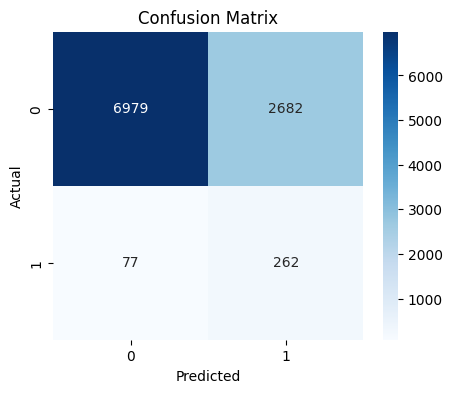

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

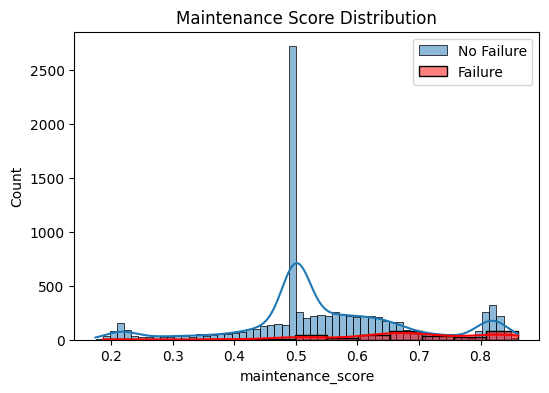

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df[df['Machine failure']==0]['maintenance_score'], label='No Failure', kde=True)
sns.histplot(df[df['Machine failure']==1]['maintenance_score'], label='Failure', kde=True, color='red')
plt.legend()
plt.title("Maintenance Score Distribution")
plt.show()

In [ ]:
# Display index, maintenance score and actual failure label
comparison_df = df[["maintenance_score", "Machine failure"]].copy()

print(comparison_df.head(20))   # first 20 rows

    maintenance_score  Machine failure
0            0.500000                0
1            0.720717                0
2            0.801489                0
3            0.491393                0
4            0.498540                0
5            0.526054                0
6            0.500000                0
7            0.499107                0
8            0.170307                0
9            0.176190                0
10           0.174163                0
11           0.578485                0
12           0.828355                0
13           0.173675                0
14           0.171096                0
15                NaN                0
16           0.772813                0
17           0.644214                0
18           0.836220                0
19           0.226741                0


In [ ]:
print(comparison_df.head(500))

     maintenance_score  Machine failure
0             0.500000                0
1             0.720717                0
2             0.801489                0
3             0.491393                0
4             0.498540                0
..                 ...              ...
495           0.854045                0
496           0.856087                0
497           0.857247                0
498           0.857993                0
499           0.858714                0

[500 rows x 2 columns]


In [ ]:
comparison_df.to_csv('comparison_df.csv', index=False)
print('comparison_df.csv has been saved. You can download it from the files pane.')

comparison_df.csv has been saved. You can download it from the files pane.


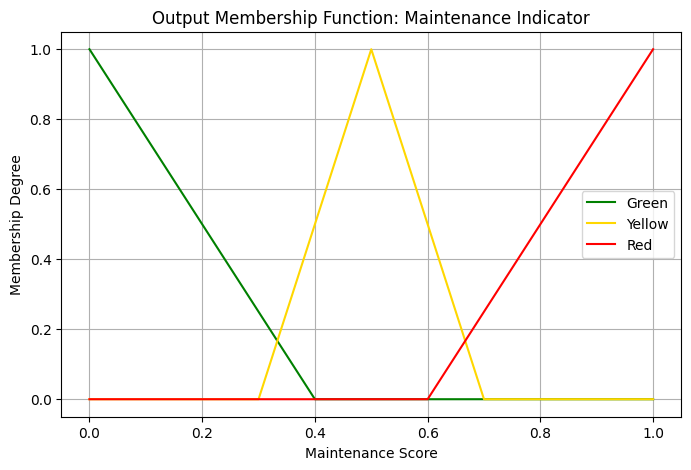

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(maintenance.universe,
         maintenance['green'].mf,
         color='green',
         label='Green')

plt.plot(maintenance.universe,
         maintenance['yellow'].mf,
         color='gold',
         label='Yellow')

plt.plot(maintenance.universe,
         maintenance['red'].mf,
         color='red',
         label='Red')

plt.title("Output Membership Function: Maintenance Indicator")
plt.xlabel("Maintenance Score")
plt.ylabel("Membership Degree")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import pandas as pd

rules_list = []

# Extract rules from control system
for i, rule in enumerate(maintenance_ctrl.rules):

    antecedent = str(rule.antecedent)
    consequent = str(rule.consequent)

    rules_list.append({
        "Rule No.": i+1,
        "IF (Condition)": antecedent,
        "THEN (Action)": consequent
    })

# Convert to DataFrame
rules_df = pd.DataFrame(rules_list)

print(rules_df)

   Rule No.                                     IF (Condition)  \
0         1                                    tool_wear[high]   
1         2  (tool_wear[medium] OR tool_wear[high]) AND tor...   
2         3                    rot_speed[low] AND torque[high]   
3         4                                 process_temp[high]   
4         5                                  tool_wear[medium]   
5         6                  tool_wear[low] AND torque[medium]   
6         7               rot_speed[low] AND tool_wear[medium]   
7         8  (tool_wear[low] AND torque[low]) AND (process_...   
8         9  ((tool_wear[low] AND torque[low]) AND rot_spee...   

           THEN (Action)  
0     [maintenance[red]]  
1     [maintenance[red]]  
2     [maintenance[red]]  
3  [maintenance[yellow]]  
4  [maintenance[yellow]]  
5  [maintenance[yellow]]  
6  [maintenance[yellow]]  
7   [maintenance[green]]  
8   [maintenance[green]]  
